<a href="https://colab.research.google.com/github/Thehxliday68/ERICA_X_MODULABS_CV/blob/main/01_SAM3/01_SAM3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# 기본 PyTorch/CUDA/OpenCV 환경은 그대로 두고, SAM3와 실습에 필요한 package만 설치합니다.
import os

# HOME 환경변수를 읽어 작업 경로를 설정합니다.
HOME = os.environ.get("HOME")
WORK_DIR = os.path.join(HOME, "work")
SAM3_ROOT = os.path.join(WORK_DIR, "sam3")

os.makedirs(WORK_DIR, exist_ok=True)

# SAM3가 아직 다운로드되지 않은 경우에만 저장소를 복제합니다.
if not os.path.exists(os.path.join(SAM3_ROOT, ".git")):
    !git clone https://github.com/facebookresearch/sam3.git "{SAM3_ROOT}"
else:
    print("SAM3 폴더가 이미 존재하므로 다운로드를 건너뜁니다.")

# SAM3와 실습에 필요한 패키지를 설치합니다.
!pip -q install -e "{SAM3_ROOT}[notebooks]"
!pip -q install -U huggingface_hub gdown

print("SAM3 설치가 완료되었습니다:", SAM3_ROOT)

SAM3 폴더가 이미 존재하므로 다운로드를 건너뜁니다.
  Installing build dependencies ... canceled
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
        reqs, check_supported_wheels=not options.target_dir
    )
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 76, in resolve
    collected = self.factory.collect_root_requirements(root_reqs)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/resolution/resolvelib/factory.py", line 538, in collect_root_requirements
    reqs = list(
        self._make_requirements_from_install_req(
    ...<2

In [16]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from PIL import Image

print("기본 라이브러리 준비 완료")

기본 라이브러리 준비 완료


In [1]:
from huggingface_hub import notebook_login

# facebook/sam3 접근 권한이 있는 Hugging Face token으로 로그인합니다.
# https://huggingface.co/facebook/sam3 에서 access 조건에 먼저 동의해야 합니다.
notebook_login()

In [2]:
from huggingface_hub import whoami

info = whoami()
print("登录成功：", info["name"])

登录成功： Thehxliday


In [3]:
import os
print(os.path.exists("/root/work/sam3/sam3"))

True


In [4]:
import os
import sys
import importlib

SAM3_ROOT = "/root/work/sam3"

if SAM3_ROOT not in sys.path:
    sys.path.insert(0, SAM3_ROOT)

importlib.invalidate_caches()

from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/root/work/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/root/work/sam3/sam3/model/model_misc.py:71: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


Device: cuda


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [6]:
import os

# Colab 런타임을 다시 시작했으므로 작업 경로를 다시 설정합니다.
HOME = os.environ.get("HOME")
WORK_DIR = os.path.join(HOME, "work")

# 데이터와 결과를 저장할 경로를 설정합니다.
DATA_DIR = os.path.join(WORK_DIR, "datasets")
RESULT_DIR = os.path.join(WORK_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("WORK_DIR:", WORK_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULT_DIR:", RESULT_DIR)

WORK_DIR: /root/work
DATA_DIR: /root/work/datasets
RESULT_DIR: /root/work/results


In [7]:
# ── 데이터 위치 ─────────────────────────────────────────────
# HOME 환경변수를 읽어 os.path.join()으로 데이터 경로를 만듭니다.
DATA_DIR = os.path.join(WORK_DIR, "datasets")
RESULT_DIR = os.path.join(WORK_DIR, "results")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

# 학습 데이터: go/stop이 섞인 운전 사진 (구글 드라이브)
TRAIN_URL = "https://drive.google.com/file/d/1kqlAqGpbjE85e9MSABbxwkD77JbrsNs8/view?usp=drive_link"
TRAIN_ROOT = os.path.join(DATA_DIR, "sam3_go_stop_train")
# 테스트 데이터: 학습에 쓰지 않은 사진 (구글 드라이브)
TEST_URL = "https://drive.google.com/file/d/1WAowcv523-z3mw2oKHS5uVL6zxXKRvwl/view?usp=drive_link"
TEST_ROOT = os.path.join(DATA_DIR, "sam3_go_stop_test")

# 공유 링크에서 파일 ID만 뽑아 gdown이 바로 받을 수 있는 주소로 바꿉니다.
TRAIN_DOWNLOAD_URL = "https://drive.google.com/uc?id=" + TRAIN_URL.split("/d/")[1].split("/")[0]
TEST_DOWNLOAD_URL = "https://drive.google.com/uc?id=" + TEST_URL.split("/d/")[1].split("/")[0]
TRAIN_ZIP = os.path.join(DATA_DIR, "sam3_go_stop_train.zip")
TEST_ZIP = os.path.join(DATA_DIR, "sam3_go_stop_test.zip")

# ── SAM3로 찾을 객체(클래스) ────────────────────────────────
# 이 prompt 목록이 곧 "어떤 단서를 볼지"를 정합니다. 사람이 직접 고른 부분이에요(= Software 1.0).
# 빨간불/초록불을 나눈 이유: 빨간불은 '정지', 초록불은 '진행'의 단서가 되기 때문이에요.
# 여기 단어를 바꾸거나 더하면 모델이 보는 단서가 달라집니다. (예: traffic cone -> barrier)
CLASSES = ["person", "bicycle", "vehicle", "red traffic light", "green traffic light", "stop sign", "animal", "traffic cone"]

# ── 검출 / feature 설정 ─────────────────────────────────────
HARVEST_CONFIDENCE = 0.5   # SAM3가 이 점수 이상으로 확신한 객체만 사용 (높일수록 확실한 것만)
MAX_OBJECTS = 20           # 한 사진에서 feature로 쓸 최대 객체 수 (이만큼만 보고 나머지는 버림)
N_PER_OBJECT = len(CLASSES) + 4         # 객체 1개당 숫자 개수 = one-hot(클래스 수) + 박스 4값
INPUT_DIM = MAX_OBJECTS * N_PER_OBJECT  # MLP 입력 길이 (객체 20개를 쭉 이어 붙인 길이)

# ── 라벨 / 학습 설정 ────────────────────────────────────────
LABEL_TO_IDX = {"go": 0, "stop": 1}   # 정답을 숫자로: go=0, stop=1
IDX_TO_LABEL = {0: "go", 1: "stop"}   # 숫자를 다시 글자로 (결과 출력용)
BATCH_SIZE = 8         # 한 번에 몇 장씩 묶어 학습할지
LEARNING_RATE = 0.001  # 학습 속도(보폭)

print("INPUT_DIM =", INPUT_DIM)
print("슝~")

INPUT_DIM = 240
슝~


In [9]:
from pathlib import Path

# 다운로드된 학습 이미지와 라벨을 다시 확인합니다.
train_items = list_images_with_labels(TRAIN_ROOT)

n_go = sum(1 for _, y in train_items if y == 0)
n_stop = sum(1 for _, y in train_items if y == 1)

print("전체 학습 이미지 수:", len(train_items))
print("Go 이미지 수:", n_go)
print("Stop 이미지 수:", n_stop)

전체 학습 이미지 수: 60
Go 이미지 수: 30
Stop 이미지 수: 30


In [10]:
os.makedirs(TRAIN_ROOT, exist_ok=True)
# gdown으로 구글 드라이브 zip을 받아 압축을 풉니다.
!gdown "{TRAIN_DOWNLOAD_URL}" -O "{TRAIN_ZIP}"
!unzip -q -o "{TRAIN_ZIP}" -d "{TRAIN_ROOT}"


# 파일 이름으로 (이미지 경로, 라벨) 목록을 만듭니다.
# 파일 이름에 정답이 들어 있어요: "stop"이 있으면 1, "go"가 있으면 0.
def list_images_with_labels(root):
    items = []
    for p in sorted(Path(root).rglob("*")):       # 폴더 안 모든 파일을 훑으며
        if p.suffix.lower() not in (".jpg", ".jpeg", ".png"):
            continue                               # 이미지 파일만 사용
        name = p.name.lower()
        if "stop" in name:
            items.append((str(p), LABEL_TO_IDX["stop"]))
        elif "go" in name:
            items.append((str(p), LABEL_TO_IDX["go"]))
    return items


train_items = list_images_with_labels(TRAIN_ROOT)
n_go = sum(1 for _, y in train_items if y == 0)
n_stop = sum(1 for _, y in train_items if y == 1)
print(f"학습 이미지: {len(train_items)}장 (go {n_go} / stop {n_stop})")

Using cookies from /root/.cache/gdown/cookies.txt
Downloading...
From (original): https://drive.google.com/uc?id=1kqlAqGpbjE85e9MSABbxwkD77JbrsNs8
From (redirected): https://drive.google.com/uc?id=1kqlAqGpbjE85e9MSABbxwkD77JbrsNs8&confirm=t&uuid=7cb0407a-ce65-4f7f-9936-60c39091e459
To: /root/work/datasets/sam3_go_stop_train.zip
100% 158M/158M [00:01<00:00, 107MB/s]
학습 이미지: 60장 (go 30 / stop 30)


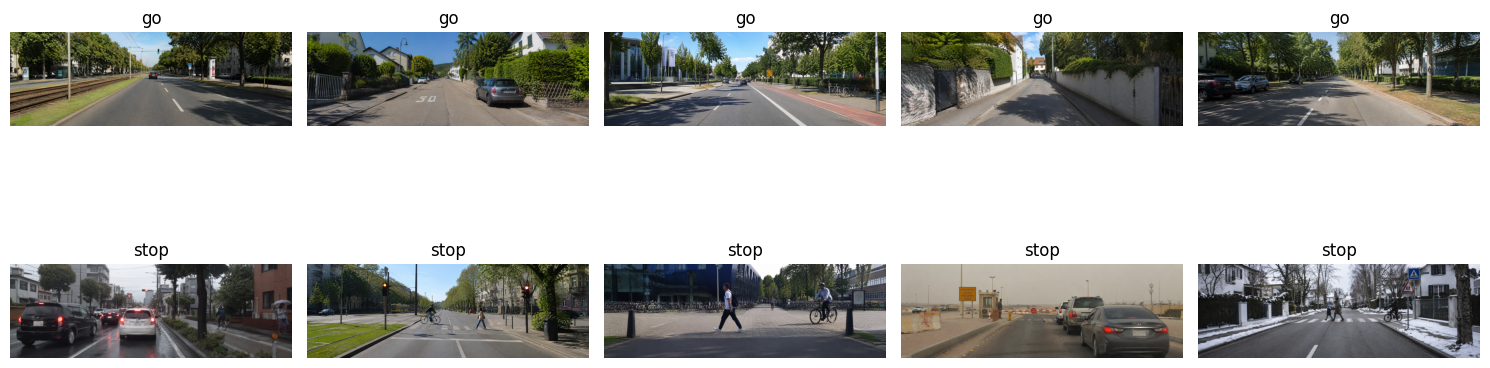

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

# 학습 데이터 목록을 go / stop으로 나눕니다. (파일명에 "go"/"stop"이 들어 있습니다.)
train_items = list_images_with_labels(TRAIN_ROOT)          # [(경로, 라벨), ...]
go_paths   = [p for p, label in train_items if label == 0][:5]   # go 5장
stop_paths = [p for p, label in train_items if label == 1][:5]   # stop 5장

# 윗줄에 go 5장, 아랫줄에 stop 5장 → 2행 5열로 배치합니다.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, path in enumerate(go_paths):
    axes[0][i].imshow(Image.open(path))
    axes[0][i].set_title("go")
    axes[0][i].axis("off")

for i, path in enumerate(stop_paths):
    axes[1][i].imshow(Image.open(path))
    axes[1][i].set_title("stop")
    axes[1][i].axis("off")

plt.tight_layout()
plt.show()

In [12]:
# 한 prompt(예: "person")로 사진에서 객체 마스크와 점수(score)를 얻습니다.
def detect_objects(processor, image, prompt, confidence=HARVEST_CONFIDENCE):
    state = processor.set_image(image)                             # 사진을 SAM3에 올림
    processor.set_confidence_threshold(confidence)                 # 검출 기준 점수 설정
    processor.reset_all_prompts(state)                             # 이전 prompt 흔적 지우기
    state = processor.set_text_prompt(prompt=prompt, state=state)  # 텍스트 prompt 적용
    return state.get("masks", []), state.get("scores", [])


# 두 마스크가 얼마나 겹치는지(IoU). 같은 물체가 두 번 잡혔는지 확인할 때 씁니다.
def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()   # 둘 다 켜진 픽셀 수 (교집합)
    union = np.logical_or(a, b).sum()    # 하나라도 켜진 픽셀 수 (합집합)
    return inter / union if union > 0 else 0.0


# 사진 한 장 -> 고정 길이(INPUT_DIM) feature 벡터로 바꿉니다.
def build_feature_vector(processor, image, iou_thr=0.5):
    # 1) 모든 클래스를 검출해, 객체 하나를
    #    [클래스번호, score, 넓이, 중심x, 아래y, 너비, 높이, mask]로 모읍니다.
    dets = []
    for class_idx, prompt in enumerate(CLASSES):
        masks, scores = detect_objects(processor, image, prompt)
        for m, s in zip(masks, scores):
            # 마스크를 numpy 2차원 boolean 배열로 정리
            m = m.detach().cpu().numpy() if isinstance(m, torch.Tensor) else np.asarray(m)
            m = np.squeeze(m).astype(bool)
            ys, xs = np.where(m)             # 마스크가 켜진 픽셀들의 좌표
            if len(xs) == 0:
                continue                     # 빈 마스크는 건너뜀
            H, W = m.shape
            # 박스 좌표를 0~1로 정규화 (사진 크기가 달라도 같은 척도가 되도록)
            x0, x1 = xs.min() / W, xs.max() / W
            y0, y1 = ys.min() / H, ys.max() / H
            w, h = x1 - x0, y1 - y0
            cx, by = (x0 + x1) / 2, y1       # 중심 x, 아래쪽 y (가까운 물체일수록 아래·크게 잡힘)
            dets.append([class_idx, float(s), w * h, cx, by, w, h, m])

    # 2) 같은 물체가 여러 prompt에 중복으로 잡힐 수 있어요.
    #    점수 높은 순으로 보며, 이미 담은 것과 많이 겹치면(IoU 큼) 버립니다. (중복 제거)
    dets.sort(key=lambda d: d[1], reverse=True)
    kept = []
    for d in dets:
        if all(mask_iou(d[7], k[7]) < iou_thr for k in kept):
            kept.append(d)

    # 3) 넓이가 큰(=대체로 가까운) 순으로 최대 MAX_OBJECTS개만 남깁니다.
    kept.sort(key=lambda d: d[2], reverse=True)
    kept = kept[:MAX_OBJECTS]

    # 4) 객체마다 한 줄씩 채웁니다: [클래스 one-hot..., 중심x, 아래y, 너비, 높이]
    #    객체가 MAX_OBJECTS보다 적으면 나머지 줄은 0으로 남습니다(= 빈 자리).
    feat = np.zeros((MAX_OBJECTS, N_PER_OBJECT), dtype=np.float32)
    for i, d in enumerate(kept):
        class_idx, cx, by, w, h = d[0], d[3], d[4], d[5], d[6]
        feat[i, class_idx] = 1.0                 # 어떤 클래스인지 one-hot으로 표시
        feat[i, len(CLASSES):] = [cx, by, w, h]  # 박스 위치·크기
    return feat.flatten()                        # 2차원 표를 한 줄로 펴서 MLP 입력으로


print("슝~")

슝~


In [13]:
sam3_model = build_sam3_image_model(device=str(device), load_from_HF=True, enable_inst_interactivity=True)
processor = Sam3Processor(sam3_model, device=str(device), confidence_threshold=0.5)
print("SAM3 model loaded")

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

SAM3 model loaded


/tmp/ipykernel_10192/1336600948.py:33: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10192/1336600948.py:33: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10192/1336600948.py:33: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10192/1336600948.py:33: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10192/1336600948.py:33: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10192/1336600948.py:33: UserWarning: Glyph 46304 (\N{HANGUL SYLLABLE DEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10192/1336600948.py:33: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  

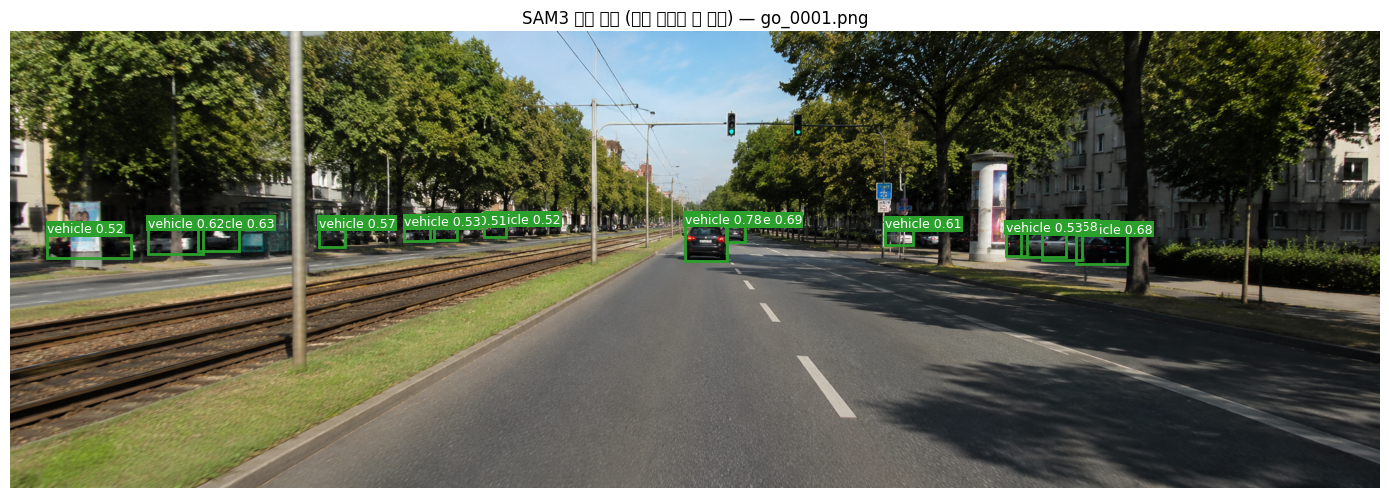

In [17]:
import matplotlib.patches as patches

# 사진 한 장에 모든 클래스를 한꺼번에 검출해 박스로 그려 봅니다.
INDEX = 0
sample_path, _ = train_items[INDEX]
sample_image = Image.open(sample_path).convert("RGB")

# 클래스마다 다른 색을 줍니다.
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASSES)))

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(sample_image)

for class_idx, prompt in enumerate(CLASSES):
    masks, scores = detect_objects(processor, sample_image, prompt)   # 이 prompt로 검출
    color = colors[class_idx]
    for m, s in zip(masks, scores):
        m = m.detach().cpu().numpy() if isinstance(m, torch.Tensor) else np.asarray(m)
        m = np.squeeze(m).astype(bool)
        ys, xs = np.where(m)
        if len(xs) == 0:
            continue
        x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
        # 박스를 그리고
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                       fill=False, edgecolor=color, linewidth=2))
        # 박스 위에 클래스 이름과 점수를 적습니다.
        ax.text(x0, max(y0 - 4, 0), f"{prompt} {float(s):.2f}",
                color='white', fontsize=9,
                bbox=dict(facecolor=color, edgecolor='none', pad=1))
ax.set_title(f"SAM3 검출 결과 (모든 클래스 한 번에) — {Path(sample_path).name}", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

In [18]:
from tqdm.auto import tqdm


# 이미지 목록을 받아, 각 사진을 feature 벡터로 바꾸고 정답과 함께 쌓습니다.
def build_feature_dataset(processor, items, desc):
    X, y = [], []
    for path, label in tqdm(items, desc=desc):           # tqdm: 진행률 표시
        image = Image.open(path).convert("RGB")
        X.append(build_feature_vector(processor, image))  # 사진 -> feature
        y.append(label)                                    # 정답(0/1)
    return np.stack(X), np.array(y, dtype=np.int64)


X, y = build_feature_dataset(processor, train_items, "학습 feature 추출")
print("X shape:", X.shape, "| y shape:", y.shape)   # X: (사진 수, INPUT_DIM)

학습 feature 추출:   0%|          | 0/60 [00:00<?, ?it/s]

X shape: (60, 240) | y shape: (60,)


In [19]:
# 학습 데이터를 train(80%)과 validation(20%)으로 나눕니다.
# train으로 배우고, val로 "처음 보는 데이터에도 잘 하나"를 확인해요.
perm = np.random.permutation(len(X))   # 순서를 무작위로 섞어서
n_train = int(len(X) * 0.8)
tr, va = perm[:n_train], perm[n_train:]

# numpy 배열을 torch tensor로 감싸 DataLoader로 묶습니다.
train_ds = TensorDataset(torch.tensor(X[tr]), torch.tensor(y[tr]))
val_ds = TensorDataset(torch.tensor(X[va]), torch.tensor(y[va]))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

print(len(train_ds), len(val_ds))

48 12


In [20]:
# 학습을 시작하기 전에 autocast를 꺼 줍니다.
torch.set_autocast_enabled('cuda', False)
print("autocast off:", torch.is_autocast_enabled('cuda')) # False 나오면 OK

autocast off: False


In [21]:
# 박스 feature(INPUT_DIM) -> go/stop(2)을 맞히는 작은 MLP입니다.
# Linear 층 3장 사이에 ReLU를 끼웠어요. 마지막 출력 2개 중 큰 쪽이 0이면 go, 1이면 stop.
model = nn.Sequential(
    nn.Linear(INPUT_DIM, 64),   # 1층: 입력 -> 64
    nn.ReLU(),
    nn.Linear(64, 32),          # 2층: 64 -> 32
    nn.ReLU(),
    nn.Linear(32, 2),           # 3층: 32 -> 2 (go/stop)
).to(device)

print(model)

Sequential(
  (0): Linear(in_features=240, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)


In [22]:
criterion = nn.CrossEntropyLoss()   # 분류 문제용 loss (예측이 정답과 얼마나 다른지)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)  # 가중치를 업데이트하는 방법


# 학습은 하지 않고 점수만 매기는 함수예요. (val 확인용)
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for i, (feats, labels) in enumerate(loader):
        feats, labels = feats.to(device), labels.to(device)
        outputs = model(feats)
        total_loss += criterion(outputs, labels).item()
        correct += (outputs.argmax(1) == labels).sum().item()   # 예측이 정답과 같은 개수
        total += labels.size(0)
    return total_loss / (i + 1), correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for feats, labels in train_loader:
            feats, labels = feats.to(device), labels.to(device)
            optimizer.zero_grad()              # 이전 기울기 초기화
            outputs = model(feats)             # 예측
            loss = criterion(outputs, labels)  # 정답과의 차이
            loss.backward()                    # 기울기 계산
            optimizer.step()                   # 가중치 업데이트
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss, train_acc = running_loss / len(train_loader), correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)   # val로 확인
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")
    return history

EPOCHS = 20
history = train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS)

Epoch 1/20 - loss: 0.7069 - accuracy: 0.3125 - val_loss: 0.6973 - val_accuracy: 0.5000
Epoch 2/20 - loss: 0.6902 - accuracy: 0.4375 - val_loss: 0.6873 - val_accuracy: 0.5833
Epoch 3/20 - loss: 0.6751 - accuracy: 0.6667 - val_loss: 0.6783 - val_accuracy: 0.5833
Epoch 4/20 - loss: 0.6576 - accuracy: 0.7292 - val_loss: 0.6684 - val_accuracy: 0.5833
Epoch 5/20 - loss: 0.6345 - accuracy: 0.8333 - val_loss: 0.6563 - val_accuracy: 0.7500
Epoch 6/20 - loss: 0.6038 - accuracy: 0.9167 - val_loss: 0.6340 - val_accuracy: 0.7500
Epoch 7/20 - loss: 0.5652 - accuracy: 0.9167 - val_loss: 0.6068 - val_accuracy: 0.6667
Epoch 8/20 - loss: 0.5146 - accuracy: 0.8958 - val_loss: 0.5715 - val_accuracy: 0.6667
Epoch 9/20 - loss: 0.4599 - accuracy: 0.8750 - val_loss: 0.5274 - val_accuracy: 0.7500
Epoch 10/20 - loss: 0.3893 - accuracy: 0.9583 - val_loss: 0.4891 - val_accuracy: 0.7500
Epoch 11/20 - loss: 0.3334 - accuracy: 0.9583 - val_loss: 0.4488 - val_accuracy: 0.7500
Epoch 12/20 - loss: 0.2836 - accuracy: 0.

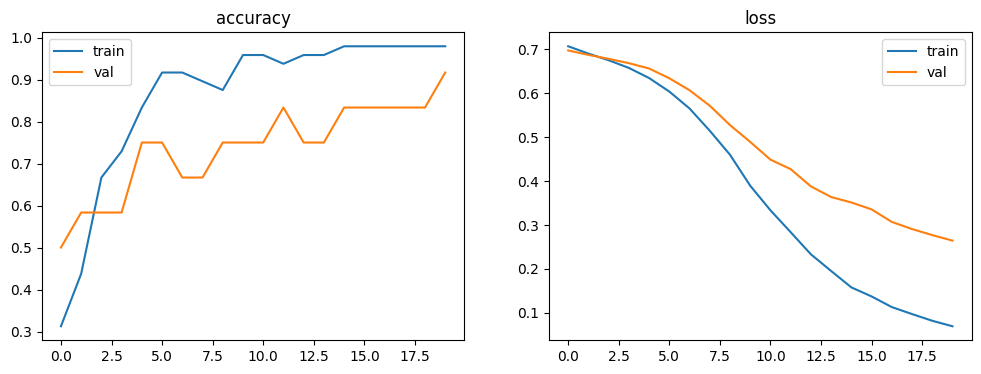

In [23]:
# 학습 곡선을 그려, 학습이 잘 되는지 / 과적합은 없는지 눈으로 확인합니다.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='train')
plt.plot(history['val_accuracy'], label='val')
plt.title('accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('loss')
plt.legend()
plt.show()

In [24]:
torch.set_autocast_enabled('cuda', True)
print("autocast off:", torch.is_autocast_enabled('cuda')) # True 나오면 OK

autocast off: True


In [25]:
os.makedirs(TEST_ROOT, exist_ok=True)
# 테스트 데이터도 같은 방식으로 받습니다.
!gdown "{TEST_DOWNLOAD_URL}" -O "{TEST_ZIP}"
!unzip -q -o "{TEST_ZIP}" -d "{TEST_ROOT}"

test_items = list_images_with_labels(TEST_ROOT)
print(f"테스트 이미지: {len(test_items)}장")

# 테스트 사진도 SAM3로 같은 feature를 뽑아 둡니다. (학습 때와 똑같은 방식)
X_test, y_test = build_feature_dataset(processor, test_items, "테스트 feature 추출")
print("X_test shape:", X_test.shape)

Using cookies from /root/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1WAowcv523-z3mw2oKHS5uVL6zxXKRvwl
To: /root/work/datasets/sam3_go_stop_test.zip
100% 7.73M/7.73M [00:00<00:00, 20.4MB/s]
테스트 이미지: 10장


테스트 feature 추출:   0%|          | 0/10 [00:00<?, ?it/s]

X_test shape: (10, 240)


In [26]:
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test).to(device))   # 테스트 feature로 예측
    preds = logits.argmax(1).cpu().numpy()             # 큰 쪽 선택 -> 0(go) / 1(stop)

# 정확도 = 맞힌 개수 / 전체 개수
correct = int((preds == y_test).sum())
print(f"정확도: {correct / len(y_test) * 100:.1f}%  ({correct}/{len(y_test)})")

정확도: 70.0%  (7/10)


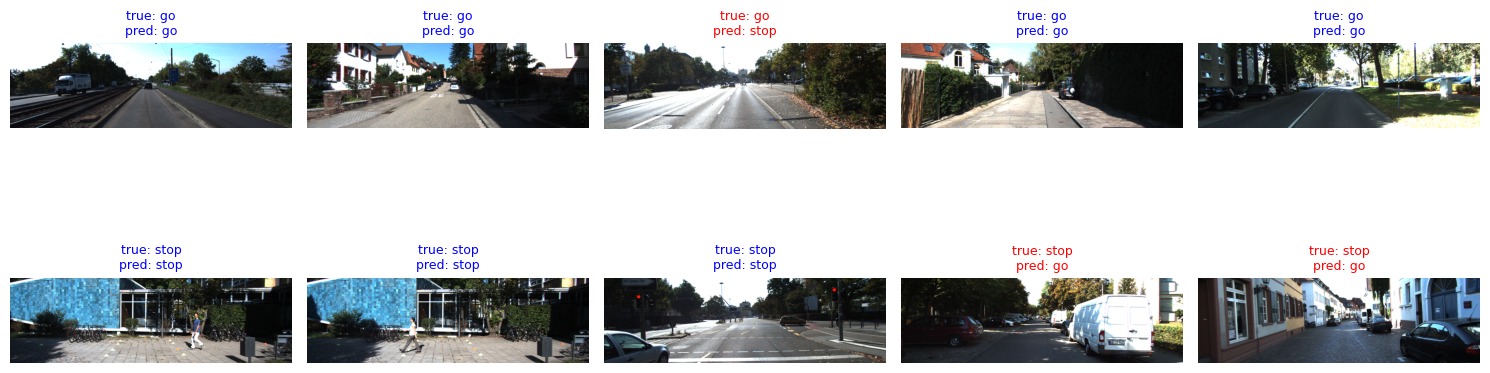

In [27]:
# 예측 결과를 5열 x 2행으로 보여 줍니다. 맞으면 파랑, 틀리면 빨강 제목.
plt.figure(figsize=(15, 6))
for i, (path, label) in enumerate(test_items):
    plt.subplot(2, 5, i + 1)   # 5열 x 2행
    plt.imshow(Image.open(path).convert("RGB"))
    color = 'blue' if preds[i] == label else 'red'
    plt.title(f"true: {IDX_TO_LABEL[label]}\npred: {IDX_TO_LABEL[preds[i]]}", color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

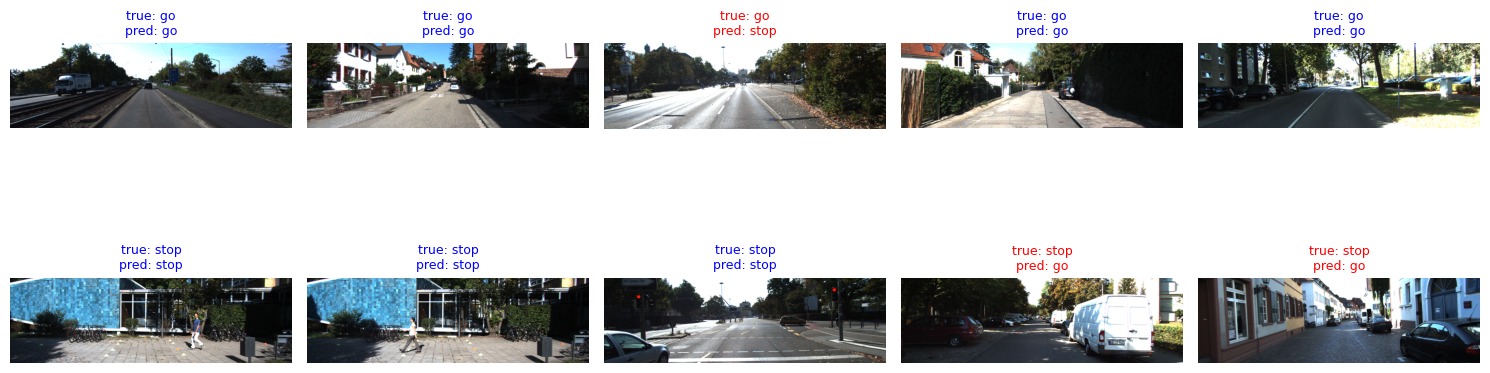

In [30]:
# 예측 결과를 5열 x 2행으로 보여 줍니다. 맞으면 파랑, 틀리면 빨강 제목.
plt.figure(figsize=(15, 6))
for i, (path, label) in enumerate(test_items):
    plt.subplot(2, 5, i + 1)   # 5열 x 2행
    plt.imshow(Image.open(path).convert("RGB"))
    color = 'blue' if preds[i] == label else 'red'
    plt.title(f"true: {IDX_TO_LABEL[label]}\npred: {IDX_TO_LABEL[preds[i]]}", color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()